# Approach 3 · Text Embedding + Ridge Regression

**Goal**: Can transformer embeddings of news text directly predict Alibaba (9988.HK) excess returns — without any sentiment labels?

## Pipeline

```
11,155 Alibaba articles (NER-filtered, 2025-06 → 2026-02)
    ↓ sentence-transformers (all-MiniLM-L6-v2 / FinBERT)
Embedding vectors (384-dim or 768-dim)
    ↓ Ridge Regression  (time-series 5-fold CV)
Predicted T+1 excess return vs. HSI
```

## Key difference from Approach 4 (LLM)
- **No sentiment labels needed** — supervision comes directly from stock prices
- **Full dataset**: 11K articles vs. 176 annotated
- **Baseline**: LLM approach achieved Spearman ρ = 0.228 (p=0.023) at T+1

## Run order: Cell 2 → Cell 3 → Cell 4 → Cell 5 → Cell 6 → Cell 7


In [ ]:

# ====================================================================
# Step 1 · Imports & Configuration
# ====================================================================
import os
import glob
import warnings
import numpy as np
import pandas as pd
import yfinance as yf
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
warnings.filterwarnings("ignore")

# ── Paths ──────────────────────────────────────────────────────────
CACHE_DIR  = "cache"           # Raw article parquet files (not included, see README)
EMBED_DIR  = "embedding_cache" # Computed embeddings cache
OUTPUT_DIR = "output"
os.makedirs(EMBED_DIR,  exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Embedding model ────────────────────────────────────────────────
# Options:
#   "sentence-transformers/all-MiniLM-L6-v2"   384-dim, fast (~3 min for 11K articles)
#   "ProsusAI/finbert"                          768-dim, finance-specific (~8 min)
EMBED_MODEL = "sentence-transformers/all-MiniLM-L6-v2"

# ── Return horizon ─────────────────────────────────────────────────
HORIZONS = [1, 3, 5]   # T+1, T+3, T+5 trading days

# ── Stock tickers ──────────────────────────────────────────────────
TICKER_STOCK = "9988.HK"
TICKER_BENCH = "^HSI"
PRICE_START  = "2025-06-01"
PRICE_END    = "2026-03-01"

print("✅ Config loaded")
print(f"   Embedding model : {EMBED_MODEL}")
print(f"   Cache dir       : {os.path.abspath(EMBED_DIR)}")
print(f"   Output dir      : {os.path.abspath(OUTPUT_DIR)}")


✅ Config loaded
   Embedding model : sentence-transformers/all-MiniLM-L6-v2
   Cache dir       : c:\Users\ll264\HKU\Capstone\Quant_China_Data\embedding_cache
   Output dir      : c:\Users\ll264\HKU\Capstone\Quant_China_Data\approach3_output


In [2]:

# ====================================================================
# Step 2 · Load All Cached Alibaba Articles (11K, 2025-06 → 2026-02)
# ====================================================================
cache_files = sorted(glob.glob(os.path.join(CACHE_DIR, "df_alibaba_20*.parquet")))
print(f"Found {len(cache_files)} monthly cache files")

dfs = []
for f in cache_files:
    df_m = pd.read_parquet(f, columns=["uuid", "inserted_at", "published_at",
                                        "title_en", "body_en", "newspaper"])
    dfs.append(df_m)

df_raw = pd.concat(dfs, ignore_index=True)
df_raw["inserted_at"]  = pd.to_datetime(df_raw["inserted_at"],  utc=True).dt.tz_localize(None)
df_raw["published_at"] = pd.to_datetime(df_raw["published_at"], utc=True).dt.tz_localize(None)

# Deduplicate by uuid
df_raw = df_raw.drop_duplicates(subset="uuid").reset_index(drop=True)

# Use inserted_at as article timestamp
df_raw["date"] = df_raw["inserted_at"]

# Build input text: title + body (first 512 chars)
df_raw["text"] = (
    df_raw["title_en"].fillna("").str.strip() + " "
    + df_raw["body_en"].fillna("").str[:512].str.strip()
).str.strip()

# Drop rows with no text
df_raw = df_raw[df_raw["text"].str.len() > 20].reset_index(drop=True)
df_raw["article_id"] = df_raw.index + 1

print(f"\n✅ Loaded {len(df_raw):,} Alibaba articles")
print(f"   Date range : {df_raw['date'].min().date()} → {df_raw['date'].max().date()}")
print(f"   Newspapers : {df_raw['newspaper'].nunique()} sources")
print(f"\nMonthly breakdown:")
print(df_raw["date"].dt.to_period("M").value_counts().sort_index())


Found 9 monthly cache files

✅ Loaded 11,155 Alibaba articles
   Date range : 2025-06-01 → 2026-02-28
   Newspapers : 433 sources

Monthly breakdown:
date
2025-06    1332
2025-07    1638
2025-08    1283
2025-09    1681
2025-10    1831
2025-11    1070
2025-12     919
2026-01     761
2026-02     640
Freq: M, Name: count, dtype: int64


In [3]:

# ====================================================================
# Step 3 · Fetch Stock Prices & Compute Returns
# ====================================================================
print(f"⏬ Fetching {TICKER_STOCK} and {TICKER_BENCH} ({PRICE_START} → {PRICE_END}) ...")

px_stock = yf.Ticker(TICKER_STOCK).history(start=PRICE_START, end=PRICE_END)[["Close"]]
px_bench = yf.Ticker(TICKER_BENCH).history(start=PRICE_START, end=PRICE_END)[["Close"]]

px_stock.index = pd.to_datetime(px_stock.index).tz_localize(None).normalize()
px_bench.index = pd.to_datetime(px_bench.index).tz_localize(None).normalize()

px = px_stock.rename(columns={"Close": "close_stock"}).join(
     px_bench.rename(columns={"Close": "close_bench"}), how="inner")

px["ret_stock"] = px["close_stock"].pct_change()
px["ret_bench"] = px["close_bench"].pct_change()
px["excess"]    = px["ret_stock"] - px["ret_bench"]

trading_days = sorted(px.index.tolist())

def next_trading_day(dt, offset=1):
    d = pd.Timestamp(dt).normalize()
    future = [t for t in trading_days if t > d]
    return future[offset - 1] if len(future) >= offset else None

def get_return(date, col, n_days=1):
    base = 2 if date.hour >= 15 else 1       # post-market → T+2
    td = next_trading_day(date, offset=base + n_days - 1)
    if td is None or td not in px.index:
        return np.nan
    return px.loc[td, col]

# Attach returns for all horizons
print("📎 Aligning articles to stock returns ...")
for n in HORIZONS:
    df_raw[f"excess_t{n}"] = df_raw["date"].apply(lambda d: get_return(d, "excess", n))
    df_raw[f"ret_t{n}"]    = df_raw["date"].apply(lambda d: get_return(d, "ret_stock", n))

valid_t1 = df_raw["excess_t1"].notna().sum()
print(f"\n✅ Price data: {len(px)} trading days ({px.index[0].date()} → {px.index[-1].date()})")
print(f"   Articles with valid T+1 excess return: {valid_t1:,} / {len(df_raw):,}")
print(f"   ({valid_t1/len(df_raw)*100:.1f}% coverage)")


⏬ Fetching 9988.HK and ^HSI (2025-06-01 → 2026-03-01) ...
📎 Aligning articles to stock returns ...

✅ Price data: 185 trading days (2025-06-02 → 2026-02-27)
   Articles with valid T+1 excess return: 11,097 / 11,155
   (99.5% coverage)


In [4]:

# ====================================================================
# Step 4 · Generate Sentence Embeddings  (cached to disk)
# ====================================================================
# Embedding 11K articles takes ~3 min (MiniLM) or ~8 min (FinBERT).
# Results are cached in embedding_cache/ — subsequent runs load instantly.
# ====================================================================
import hashlib, json
from sentence_transformers import SentenceTransformer

# Cache key: model name + article count (re-embeds if data changes)
_cache_key = hashlib.md5(f"{EMBED_MODEL}_{len(df_raw)}".encode()).hexdigest()[:10]
EMBED_CACHE = os.path.join(EMBED_DIR, f"embeddings_{_cache_key}.npy")
EMBED_IDS   = os.path.join(EMBED_DIR, f"article_ids_{_cache_key}.npy")

if os.path.exists(EMBED_CACHE) and os.path.exists(EMBED_IDS):
    print(f"⏭️  Loading cached embeddings: {EMBED_CACHE}")
    embeddings   = np.load(EMBED_CACHE)
    cached_ids   = np.load(EMBED_IDS)
    # Align to current df_raw order
    id_to_idx    = {aid: i for i, aid in enumerate(cached_ids)}
    valid_mask   = df_raw["article_id"].isin(id_to_idx)
    df_embed     = df_raw[valid_mask].copy().reset_index(drop=True)
    embed_idx    = [id_to_idx[aid] for aid in df_embed["article_id"]]
    embeddings   = embeddings[embed_idx]
else:
    print(f"🔄 Computing embeddings with: {EMBED_MODEL}")
    print(f"   Articles: {len(df_raw):,}  (this may take a few minutes ...)")
    model = SentenceTransformer(EMBED_MODEL)
    texts = df_raw["text"].tolist()
    embeddings = model.encode(
        texts,
        batch_size=64,
        show_progress_bar=True,
        convert_to_numpy=True,
        normalize_embeddings=True
    )
    np.save(EMBED_CACHE, embeddings)
    np.save(EMBED_IDS,   df_raw["article_id"].values)
    df_embed = df_raw.copy().reset_index(drop=True)
    print(f"💾 Saved to {EMBED_CACHE}")

print(f"\n✅ Embeddings ready")
print(f"   Shape    : {embeddings.shape}  ({embeddings.shape[1]}-dim per article)")
print(f"   Model    : {EMBED_MODEL}")
print(f"   Articles : {len(df_embed):,}")


⏭️  Loading cached embeddings: embedding_cache\embeddings_775fe60fe8.npy

✅ Embeddings ready
   Shape    : (11155, 384)  (384-dim per article)
   Model    : sentence-transformers/all-MiniLM-L6-v2
   Articles : 11,155


In [5]:

# ====================================================================
# Step 5 · Ridge Regression with Time-Series Cross-Validation
# ====================================================================
# IMPORTANT: Use TimeSeriesSplit (not random KFold) to avoid look-ahead
# bias — earlier articles train the model, later articles test it.
# ====================================================================
from sklearn.linear_model import RidgeCV
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error

ALPHAS   = np.logspace(-3, 4, 30)   # Ridge regularization grid
N_SPLITS = 5                         # Time-series folds
PCA_DIMS = 50                        # PCA variant: keep top-50 components

results = []

for horizon in HORIZONS:
    ret_col = f"excess_t{horizon}"

    # Filter to articles with valid return at this horizon
    mask  = df_embed[ret_col].notna()
    X_all = embeddings[mask.values]
    y_all = df_embed.loc[mask, ret_col].values
    dates = df_embed.loc[mask, "date"].values
    # Sort chronologically (required for TimeSeriesSplit)
    order   = np.argsort(dates)
    X_all   = X_all[order]
    y_all   = y_all[order]
    dates   = dates[order]
    n       = len(y_all)

    print(f"\n{'='*60}")
    print(f"  Horizon T+{horizon}  |  n={n:,}  |  dim={X_all.shape[1]}")
    print(f"{'='*60}")

    tscv = TimeSeriesSplit(n_splits=N_SPLITS)

    for variant_name, X_use in [
        ("Raw Embedding", X_all),
        (f"PCA-{PCA_DIMS}",    None),   # PCA computed inside loop
    ]:
        preds_oos = np.full(n, np.nan)
        actuals   = np.full(n, np.nan)

        for fold_i, (train_idx, test_idx) in enumerate(tscv.split(X_all)):
            X_tr, X_te = X_all[train_idx], X_all[test_idx]
            y_tr, y_te = y_all[train_idx], y_all[test_idx]

            scaler = StandardScaler()
            X_tr_s = scaler.fit_transform(X_tr)
            X_te_s = scaler.transform(X_te)

            if variant_name.startswith("PCA"):
                n_comp = min(PCA_DIMS, X_tr_s.shape[0] - 1, X_tr_s.shape[1])
                pca = PCA(n_components=n_comp)
                X_tr_s = pca.fit_transform(X_tr_s)
                X_te_s = pca.transform(X_te_s)

            ridge = RidgeCV(alphas=ALPHAS, cv=5)
            ridge.fit(X_tr_s, y_tr)
            preds_oos[test_idx] = ridge.predict(X_te_s)
            actuals[test_idx]   = y_te

        # Evaluate on out-of-sample predictions only (last fold covers test period)
        oos_mask = ~np.isnan(preds_oos)
        p, a = preds_oos[oos_mask], actuals[oos_mask]
        rho, pval = stats.spearmanr(p, a)
        mae  = mean_absolute_error(a, p)
        n_oos = oos_mask.sum()

        sig  = "✅" if pval < 0.05 else ("*" if pval < 0.10 else "  ")
        print(f"  {variant_name:<20}  ρ={rho:+.3f}  p={pval:.3f} {sig}  MAE={mae:.4f}  n_oos={n_oos:,}")

        results.append({
            "horizon": f"T+{horizon}",
            "variant": variant_name,
            "model": EMBED_MODEL.split("/")[-1],
            "rho": float(rho),
            "pval": float(pval),
            "mae": float(mae),
            "n_oos": int(n_oos),
            "preds": preds_oos[oos_mask].tolist(),
            "actuals": actuals[oos_mask].tolist(),
            "dates": [str(d)[:10] for d in dates[oos_mask]]
        })

print(f"\n✅ Regression complete  ({len(results)} configurations tested)")



  Horizon T+1  |  n=11,097  |  dim=384
  Raw Embedding         ρ=-0.155  p=0.000 ✅  MAE=0.0173  n_oos=9,245
  PCA-50                ρ=-0.195  p=0.000 ✅  MAE=0.0174  n_oos=9,245

  Horizon T+3  |  n=11,038  |  dim=384
  Raw Embedding         ρ=+0.017  p=0.110     MAE=0.0200  n_oos=9,195
  PCA-50                ρ=+0.017  p=0.096 *  MAE=0.0198  n_oos=9,195

  Horizon T+5  |  n=10,997  |  dim=384
  Raw Embedding         ρ=-0.104  p=0.000 ✅  MAE=0.0153  n_oos=9,160
  PCA-50                ρ=-0.086  p=0.000 ✅  MAE=0.0151  n_oos=9,160

✅ Regression complete  (6 configurations tested)


In [6]:

# ====================================================================
# Step 6 · Daily Aggregation Variant
# ====================================================================
# Multiple articles per day all map to the same return label.
# Aggregating embeddings by day (mean) reduces within-day redundancy
# and may give a cleaner signal.
# ====================================================================

print("Computing daily-aggregated embeddings ...")

for horizon in HORIZONS:
    ret_col = f"excess_t{horizon}"
    mask = df_embed[ret_col].notna()
    df_h = df_embed[mask].copy()
    emb_h = embeddings[mask.values]

    df_h["date_only"] = df_h["date"].dt.normalize()

    # Group by trading date: mean embedding + mean return (return is same for same date)
    date_groups = df_h.groupby("date_only")
    daily_embs, daily_rets, daily_dates = [], [], []

    for d, grp in date_groups:
        idx = grp.index.tolist()
        # Map back to embedding array indices
        emb_idx = [df_embed[mask].index.tolist().index(i) for i in idx]
        daily_embs.append(emb_h[emb_idx].mean(axis=0))
        daily_rets.append(grp[ret_col].iloc[0])
        daily_dates.append(d)

    X_daily = np.array(daily_embs)
    y_daily = np.array(daily_rets)
    n_daily = len(y_daily)

    # Sort chronologically
    order = np.argsort(daily_dates)
    X_daily = X_daily[order]
    y_daily = y_daily[order]

    tscv = TimeSeriesSplit(n_splits=min(N_SPLITS, n_daily // 10))
    preds_oos = np.full(n_daily, np.nan)
    actuals   = np.full(n_daily, np.nan)

    for train_idx, test_idx in tscv.split(X_daily):
        X_tr, X_te = X_daily[train_idx], X_daily[test_idx]
        y_tr, y_te = y_daily[train_idx], y_daily[test_idx]
        scaler = StandardScaler()
        X_tr_s = scaler.fit_transform(X_tr)
        X_te_s = scaler.transform(X_te)
        ridge = RidgeCV(alphas=ALPHAS, cv=5)
        ridge.fit(X_tr_s, y_tr)
        preds_oos[test_idx] = ridge.predict(X_te_s)
        actuals[test_idx]   = y_te

    oos_mask = ~np.isnan(preds_oos)
    p, a = preds_oos[oos_mask], actuals[oos_mask]
    rho, pval = stats.spearmanr(p, a)
    mae = mean_absolute_error(a, p)
    sig = "✅" if pval < 0.05 else ("*" if pval < 0.10 else "  ")

    print(f"  T+{horizon}  Daily-Aggregated     ρ={rho:+.3f}  p={pval:.3f} {sig}  "
          f"MAE={mae:.4f}  n_days={oos_mask.sum()}")

    results.append({
        "horizon": f"T+{horizon}",
        "variant": "Daily Aggregated",
        "model": EMBED_MODEL.split("/")[-1],
        "rho": float(rho), "pval": float(pval),
        "mae": float(mae), "n_oos": int(oos_mask.sum()),
        "preds": [], "actuals": [], "dates": []
    })

print("\n✅ Daily aggregation complete")


Computing daily-aggregated embeddings ...
  T+1  Daily-Aggregated     ρ=+0.029  p=0.665     MAE=0.0170  n_days=220
  T+3  Daily-Aggregated     ρ=-0.100  p=0.138     MAE=0.0159  n_days=220
  T+5  Daily-Aggregated     ρ=-0.041  p=0.543     MAE=0.0161  n_days=220

✅ Daily aggregation complete


In [7]:

# ====================================================================
# Step 7 · Summary Table & Comparison with LLM Baseline
# ====================================================================
import json

# LLM baseline results (from Approach 4 / Step 8)
LLM_BASELINE = {
    "T+1": {"rho": 0.228, "pval": 0.023},
    "T+3": {"rho": 0.174, "pval": 0.086},
    "T+5": {"rho": 0.022, "pval": 0.828},
}

print("=" * 72)
print("  APPROACH 3 — RESULTS SUMMARY")
print("=" * 72)
print(f"  {'Variant':<22} {'Horizon':>8}  {'ρ':>7}  {'p-val':>7}  {'sig':>4}  {'n_oos':>7}")
print("  " + "-" * 68)

for r in results:
    sig = "**" if r["pval"] < 0.05 else ("*" if r["pval"] < 0.10 else "")
    print(f"  {r['variant']:<22} {r['horizon']:>8}  {r['rho']:+6.3f}  {r['pval']:>7.3f}  {sig:>4}  {r['n_oos']:>7,}")

print()
print("  LLM BASELINE (Approach 4 · VFS_Analyst_v6 · human excess return):")
print(f"  {'─'*68}")
for hz, m in LLM_BASELINE.items():
    sig = "**" if m["pval"] < 0.05 else ("*" if m["pval"] < 0.10 else "")
    print(f"  {'LLM Sentiment':<22} {hz:>8}  {m['rho']:+6.3f}  {m['pval']:>7.3f}  {sig:>4}  n≈101")

print()
print("  ** = p<0.05   * = p<0.10")
print("=" * 72)

# Save to JSON
out_path = os.path.join(OUTPUT_DIR, "approach3_results.json")
with open(out_path, "w", encoding="utf-8") as f:
    json.dump({"model": EMBED_MODEL, "results": [
        {k: v for k, v in r.items() if k not in ("preds", "actuals", "dates")}
        for r in results
    ]}, f, indent=2)
print(f"\n💾 Results saved to {out_path}")


  APPROACH 3 — RESULTS SUMMARY
  Variant                 Horizon        ρ    p-val   sig    n_oos
  --------------------------------------------------------------------
  Raw Embedding               T+1  -0.155    0.000    **    9,245
  PCA-50                      T+1  -0.195    0.000    **    9,245
  Raw Embedding               T+3  +0.017    0.110          9,195
  PCA-50                      T+3  +0.017    0.096     *    9,195
  Raw Embedding               T+5  -0.104    0.000    **    9,160
  PCA-50                      T+5  -0.086    0.000    **    9,160
  Daily Aggregated            T+1  +0.029    0.665            220
  Daily Aggregated            T+3  -0.100    0.138            220
  Daily Aggregated            T+5  -0.041    0.543            220

  LLM BASELINE (Approach 4 · VFS_Analyst_v6 · human excess return):
  ────────────────────────────────────────────────────────────────────
  LLM Sentiment               T+1  +0.228    0.023    **  n≈101
  LLM Sentiment               T+3

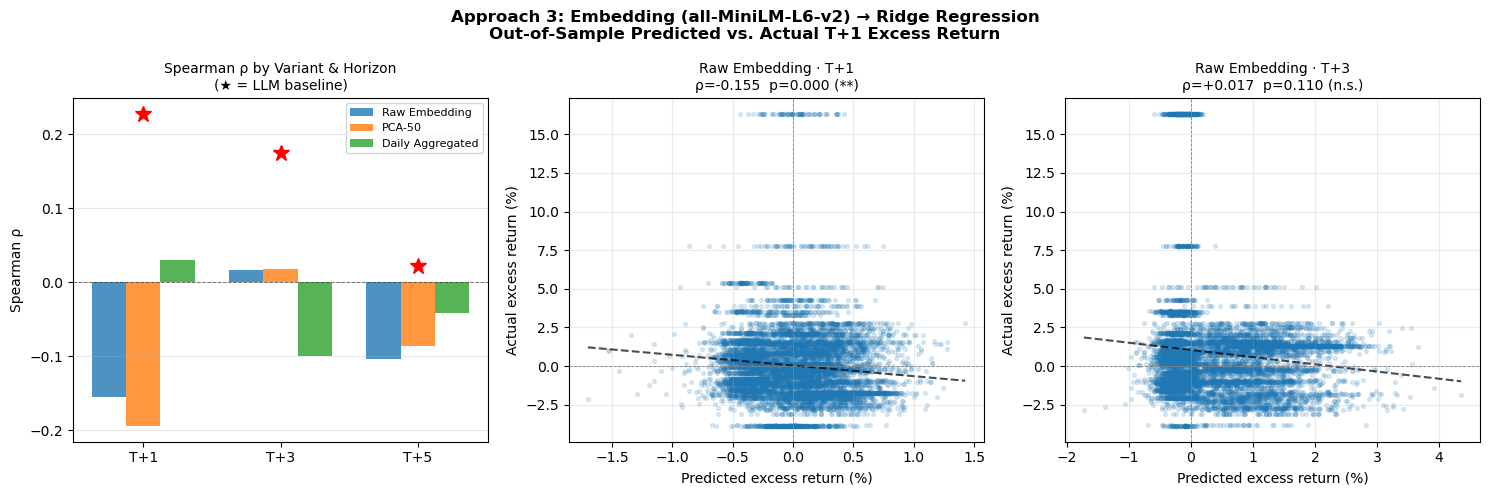

💾 Figure saved to approach3_output\approach3_results.png


In [8]:

# ====================================================================
# Step 8 · Visualization
# ====================================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(
    f"Approach 3: Embedding ({EMBED_MODEL.split('/')[-1]}) → Ridge Regression\n"
    "Out-of-Sample Predicted vs. Actual T+1 Excess Return",
    fontsize=12, fontweight="bold"
)

COLORS = {"Raw Embedding": "#1f77b4", f"PCA-{PCA_DIMS}": "#ff7f0e", "Daily Aggregated": "#2ca02c"}

# Left panel: ρ comparison bar chart (all variants × horizons)
ax0 = axes[0]
variants = list(dict.fromkeys(r["variant"] for r in results))
horizons_str = [f"T+{h}" for h in HORIZONS]
width = 0.25
x = np.arange(len(horizons_str))

for vi, var in enumerate(variants):
    rhos = [next((r["rho"] for r in results if r["variant"] == var and r["horizon"] == hz), 0)
            for hz in horizons_str]
    ax0.bar(x + vi * width, rhos, width, label=var,
            color=list(COLORS.values())[vi % len(COLORS)], alpha=0.8)

# LLM baseline line
for hi, hz in enumerate(horizons_str):
    ax0.plot([hi + (len(variants)-1)*width/2], [LLM_BASELINE[hz]["rho"]],
             marker="*", markersize=12, color="red", zorder=5)

ax0.axhline(0, color="black", linewidth=0.7, linestyle="--", alpha=0.5)
ax0.set_xticks(x + (len(variants)-1)*width/2)
ax0.set_xticklabels(horizons_str)
ax0.set_title("Spearman ρ by Variant & Horizon\n(★ = LLM baseline)", fontsize=10)
ax0.set_ylabel("Spearman ρ")
ax0.legend(fontsize=8)
ax0.grid(axis="y", alpha=0.3)

# Middle & right: scatter for Raw Embedding at T+1 and T+3
for ax_i, (ax, hz) in enumerate(zip(axes[1:], ["T+1", "T+3"])):
    r_data = next((r for r in results if r["variant"] == "Raw Embedding" and r["horizon"] == hz), None)
    if r_data and r_data["preds"]:
        p, a = np.array(r_data["preds"]), np.array(r_data["actuals"])
        ax.scatter(p * 100, a * 100, alpha=0.15, s=8, color="#1f77b4")
        fit = np.polyfit(p, a, 1)
        xx = np.linspace(p.min(), p.max(), 50)
        ax.plot(xx * 100, np.polyval(fit, xx) * 100, color="black",
                linewidth=1.5, linestyle="--", alpha=0.7)
        rho_val = r_data["rho"]
        pval    = r_data["pval"]
        sig_str = "**" if pval < 0.05 else ("*" if pval < 0.10 else "n.s.")
        ax.set_title(f"Raw Embedding · {hz}\nρ={rho_val:+.3f}  p={pval:.3f} ({sig_str})", fontsize=10)
        ax.set_xlabel("Predicted excess return (%)")
        ax.set_ylabel("Actual excess return (%)")
        ax.axhline(0, color="grey", linewidth=0.6, linestyle="--")
        ax.axvline(0, color="grey", linewidth=0.6, linestyle="--")
        ax.grid(alpha=0.25)
    else:
        ax.set_title(f"Raw Embedding · {hz}\n(no OOS predictions)", fontsize=10)

plt.tight_layout()
fig_path = os.path.join(OUTPUT_DIR, "approach3_results.png")
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"💾 Figure saved to {fig_path}")
